## Лабораторная 8 — Оффлайн оценивание РС (улучшенная версия)

**Агенты:**
- **Агент A (SVD-100)** — лучшая модель из лабы 7
- **Агент B (Гибрид CB→SVD)** — лучшая модель из лабы 6

**Улучшения по сравнению с v1:**
1. **Logging policy — popularity-based** (а не SVD-50): показывает популярные аниме чаще, редкие — реже. Это создаёт реальный selection bias и делает IPS-веса содержательными.
2. **Weight clipping** (`w ≤ 5.0`) — стабилизирует IPS при выбросах весов.
3. **Сегментация пользователей** — cold (≤20 оценок) vs warm (>20) — видно где какая модель реально лучше.

## 1. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from surprise import SVD, Reader, Dataset
from surprise.model_selection import train_test_split as surprise_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Все библиотеки загружены.")

Все библиотеки загружены.


## 2. Загрузка данных

In [2]:
anime_df  = pd.read_csv('anime_enriched.csv')
rating_df = pd.read_csv('rating.csv')

rating_df = rating_df[rating_df['rating'] != -1]
anime_df['genre']    = anime_df['genre'].fillna('Unknown')
anime_df['type']     = anime_df['type'].fillna('Unknown')
anime_df['synopsis'] = anime_df['synopsis'].fillna('')

anime_df['genre_clean'] = anime_df['genre'].str.replace(',', ' ').str.lower()
anime_df['type_clean']  = anime_df['type'].str.lower()
anime_df['episodes']    = pd.to_numeric(anime_df['episodes'], errors='coerce').fillna(12)
anime_df['ep_cat']      = anime_df['episodes'].apply(
    lambda x: 'short' if x <= 13 else ('medium' if x <= 26 else 'long'))
anime_df['combined_v2'] = (anime_df['genre_clean'] + ' ' + anime_df['type_clean'] + ' ' +
                            anime_df['synopsis'].str.lower() + ' ' + anime_df['ep_cat'])

anime_id_to_idx = dict(zip(anime_df['anime_id'], anime_df.index))
idx_to_anime_id = dict(zip(anime_df.index,       anime_df['anime_id']))

train_data, test_data = train_test_split(rating_df, test_size=0.2, random_state=42)

# популярность аниме (нужна для logging policy)
anime_popularity = rating_df.groupby('anime_id').size().reset_index(name='n_ratings')
anime_df = anime_df.merge(anime_popularity, on='anime_id', how='left')
anime_df['n_ratings'] = anime_df['n_ratings'].fillna(1)

print(f"Аниме:        {len(anime_df)}")
print(f"Оценок:       {len(rating_df):,}")
print(f"Train / Test: {len(train_data):,} / {len(test_data):,}")

Аниме:        12294
Оценок:       6,337,241
Train / Test: 5,069,792 / 1,267,449


## 3. Подготовка моделей

In [3]:
print("TF-IDF матрица...")
tfidf        = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(anime_df['combined_v2'])
cosine_sim   = cosine_similarity(tfidf_matrix, tfidf_matrix)

user_means         = train_data.groupby('user_id')['rating'].mean()
global_mean        = train_data['rating'].mean()
user_watched_cache = {}
for uid, group in train_data.groupby('user_id'):
    ids, rats = group['anime_id'].values, group['rating'].values.astype(float)
    valid = [(anime_id_to_idx[a], r) for a, r in zip(ids, rats) if a in anime_id_to_idx]
    if valid:
        idxs, rs = zip(*valid)
        user_watched_cache[uid] = (np.array(idxs), np.array(rs))

print("Обучение SVD-100 (Агент A)...")
reader   = Reader(rating_scale=(1, 10))
data_sur = Dataset.load_from_df(rating_df[['user_id', 'anime_id', 'rating']], reader)
trainset, _ = surprise_split(data_sur, test_size=0.2, random_state=42)
svd_model = SVD(n_factors=100, n_epochs=20, random_state=42, verbose=False)
svd_model.fit(trainset)
print("Готово!")

TF-IDF матрица...
Обучение SVD-100 (Агент A)...
Готово!


## 4. Функции предсказания агентов

In [4]:
def predict_svd(user_id, anime_id):
    return svd_model.predict(user_id, anime_id, verbose=False).est

def predict_cb(user_id, anime_id, k=20, min_sim=0.05):
    if anime_id not in anime_id_to_idx or user_id not in user_watched_cache:
        return float(user_means.get(user_id, global_mean))
    target_idx     = anime_id_to_idx[anime_id]
    idxs, rats     = user_watched_cache[user_id]
    sims           = cosine_sim[target_idx, idxs]
    mask           = sims > min_sim
    if mask.sum() == 0:
        return float(user_means.get(user_id, global_mean))
    sims_f, rats_f = sims[mask], rats[mask]
    if len(sims_f) > k:
        top_k = np.argpartition(sims_f, -k)[-k:]
        sims_f, rats_f = sims_f[top_k], rats_f[top_k]
    user_mean = float(user_means.get(user_id, global_mean))
    return float(user_mean + np.average(rats_f - user_mean, weights=sims_f))

def predict_hybrid(user_id, anime_id):
    return 0.3 * predict_cb(user_id, anime_id) + 0.7 * predict_svd(user_id, anime_id)

print("Агент A: SVD-100")
print("Агент B: Гибрид (CB→SVD)")

Агент A: SVD-100
Агент B: Гибрид (CB→SVD)


## 5. Улучшение 1 Popularity-based logging policy

В реальных системах лог собирается не идеальной моделью, а той что была в продакшне —
обычно popularity-based (показывают популярное) с элементом случайности (exploration).

Мы моделируем это так:
- Вероятность показа аниме пользователю ∝ его популярность + случайный шум
- Это создаёт реальный selection bias: популярные аниме переставлены, редкие — недопредставлены
- Из-за этого IPS-веса будут реально отличаться от 1 → метод становится содержательным

In [5]:
# Строим popularity-based propensity для каждой записи в логе
log_sample = test_data.sample(n=min(3000, len(test_data)), random_state=42).copy()

# Popularity score для каждого аниме (нормализованный log-popularity)
pop_map = dict(zip(anime_df['anime_id'], anime_df['n_ratings']))
log_sample['pop_score'] = log_sample['anime_id'].map(pop_map).fillna(1)

print("Распределение popularity scores:")
print(f"  мин={log_sample['pop_score'].min():.0f}, "
      f"макс={log_sample['pop_score'].max():.0f}, "
      f"медиана={log_sample['pop_score'].median():.0f}")

# Logging propensity = softmax(log(popularity) + шум) по пользователю
# Шум нужен чтобы имитировать exploration в logging policy
MIN_PROPENSITY = 0.005   # более жёсткий клиппинг
NOISE_SCALE    = 0.5     # масштаб случайного шума (чем больше — тем случайнее политика)

log_sample['log_propensity'] = 0.0

for uid, group in log_sample.groupby('user_id'):
    pop    = np.log1p(group['pop_score'].values).astype(float)
    noise  = np.random.normal(0, NOISE_SCALE, size=len(pop))
    scores = pop + noise
    exp_s  = np.exp(scores - scores.max())
    probs  = exp_s / exp_s.sum()
    log_sample.loc[group.index, 'log_propensity'] = probs

log_sample['log_propensity'] = log_sample['log_propensity'].clip(lower=MIN_PROPENSITY)

print(f"\nLogging propensity scores:")
print(f"  мин={log_sample['log_propensity'].min():.5f}, "
      f"макс={log_sample['log_propensity'].max():.5f}, "
      f"среднее={log_sample['log_propensity'].mean():.5f}")
print(f"  std={log_sample['log_propensity'].std():.5f}")
display(log_sample[['user_id', 'anime_id', 'rating', 'pop_score', 'log_propensity']].head(5))

Распределение popularity scores:
  мин=1, макс=34226, медиана=3790

Logging propensity scores:
  мин=0.00500, макс=1.00000, среднее=0.94167
  std=0.19155


,user_id,anime_id,rating,pop_score,log_propensity
7339534,68387,486,10,2215.0,1.0
4223646,40032,11433,9,5171.0,1.0
1702387,16482,1142,9,2465.0,1.0
3106330,28712,3841,8,863.0,1.0
2131952,20637,13939,7,2090.0,1.0


## 6. Улучшение 2 — Weight clipping в IPS/SNIPS

Без клиппинга один большой вес может исказить всю оценку IPS.  
Стандартная практика: обрезаем веса сверху (`w_max = 5.0`).  
SNIPS это компенсирует автоматически через нормализацию.

In [6]:
def compute_target_propensity(policy_fn, log_df):
    """Propensity целевой политики через softmax предсказаний."""
    preds = np.array([policy_fn(r['user_id'], r['anime_id'])
                      for _, r in log_df.iterrows()])
    target_props = np.zeros(len(log_df))
    log_reset    = log_df.reset_index(drop=True)
    for uid, grp_idx in log_reset.groupby('user_id').groups.items():
        p     = preds[grp_idx]
        exp_p = np.exp(p - p.max())
        target_props[grp_idx] = exp_p / exp_p.sum()
    return preds, np.clip(target_props, MIN_PROPENSITY, None)


def direct_method(policy_preds, actual):
    rewards = np.maximum(0, 1 - np.abs(policy_preds - actual) / 9)
    return float(np.mean(rewards))

def ips(actual, log_props, target_props, clip=5.0):
    """IPS с weight clipping."""
    rewards = np.maximum(0, 1 - np.abs(actual - actual.mean()) / 9)
    weights = np.clip(target_props / log_props, 0, clip)   # ← клиппинг
    return float(np.mean(weights * rewards))

def snips(actual, log_props, target_props, clip=5.0):
    """SNIPS с weight clipping — наиболее устойчивый метод."""
    rewards = np.maximum(0, 1 - np.abs(actual - actual.mean()) / 9)
    weights = np.clip(target_props / log_props, 0, clip)   # ← клиппинг
    return float(np.sum(weights * rewards) / np.sum(weights))

def ess(log_props, target_props, clip=5.0):
    """Effective Sample Size — насколько надёжна IPS-оценка."""
    w = np.clip(target_props / log_props, 0, clip)
    return (w.sum()**2) / (w**2).sum()

print("Функции оценки с weight clipping (clip=5.0) готовы.")

Функции оценки с weight clipping (clip=5.0) готовы.


## 7. Оценка агентов

In [7]:
actual    = log_sample['rating'].values.astype(float)
log_props = log_sample['log_propensity'].values

print("Оценка Агента A (SVD-100)...")
preds_a, tprops_a = compute_target_propensity(predict_svd, log_sample)

print("Оценка Агента B (Гибрид CB→SVD)...")
preds_b, tprops_b = compute_target_propensity(predict_hybrid, log_sample)

# метрики
dm_a    = direct_method(preds_a, actual)
ips_a   = ips(actual, log_props, tprops_a)
snips_a = snips(actual, log_props, tprops_a)
rmse_a  = sqrt(mean_squared_error(actual, preds_a))
mae_a   = mean_absolute_error(actual, preds_a)
ess_a   = ess(log_props, tprops_a)

dm_b    = direct_method(preds_b, actual)
ips_b   = ips(actual, log_props, tprops_b)
snips_b = snips(actual, log_props, tprops_b)
rmse_b  = sqrt(mean_squared_error(actual, preds_b))
mae_b   = mean_absolute_error(actual, preds_b)
ess_b   = ess(log_props, tprops_b)

results = pd.DataFrame([
    {'Агент': 'A — SVD-100',
     'DM': round(dm_a,4), 'IPS': round(ips_a,4), 'SNIPS': round(snips_a,4),
     'RMSE': round(rmse_a,4), 'MAE': round(mae_a,4),
     'ESS%': f"{ess_a/len(actual)*100:.1f}%"},
    {'Агент': 'B — Гибрид (CB→SVD)',
     'DM': round(dm_b,4), 'IPS': round(ips_b,4), 'SNIPS': round(snips_b,4),
     'RMSE': round(rmse_b,4), 'MAE': round(mae_b,4),
     'ESS%': f"{ess_b/len(actual)*100:.1f}%"},
])

print("\nИтоговая таблица:\n")
display(results)

for col, higher_better in [('DM',True),('IPS',True),('SNIPS',True),('RMSE',False),('MAE',False)]:
    vals  = [dm_a,ips_a,snips_a,rmse_a,mae_a] if col=='DM' else             [ips_a,ips_b] if col=='IPS' else             [snips_a,snips_b] if col=='SNIPS' else             [rmse_a,rmse_b] if col=='RMSE' else [mae_a,mae_b]
    if col in ['DM','IPS','SNIPS']:
        va, vb = (dm_a,dm_b) if col=='DM' else (ips_a,ips_b) if col=='IPS' else (snips_a,snips_b)
        best   = 'A (SVD-100)' if va>vb else 'B (Гибрид)'
        bv     = max(va,vb)
    else:
        va, vb = (rmse_a,rmse_b) if col=='RMSE' else (mae_a,mae_b)
        best   = 'A (SVD-100)' if va<vb else 'B (Гибрид)'
        bv     = min(va,vb)
    print(f"  {col:<6} → лучший: {best} ({bv:.4f})")

Оценка Агента A (SVD-100)...
Оценка Агента B (Гибрид CB→SVD)...

Итоговая таблица:



,Агент,DM,IPS,SNIPS,RMSE,MAE,ESS%
0,A — SVD-100,0.9345,0.9098,0.8603,0.785,0.5891,82.2%
1,B — Гибрид (CB→SVD),0.9249,0.9149,0.8596,0.895,0.6756,81.7%


  DM     → лучший: A (SVD-100) (0.9345)
  IPS    → лучший: B (Гибрид) (0.9149)
  SNIPS  → лучший: A (SVD-100) (0.8603)
  RMSE   → лучший: A (SVD-100) (0.7850)
  MAE    → лучший: A (SVD-100) (0.5891)


## 8. Анализ IPS-весов (сравнение v1 vs v2)

Агент A — SVD-100:
  Веса: мин=0.007, макс=5.000, среднее=1.058, std=0.492
  ESS: 2466 из 3000 (82.2%)
  ESS > 50% — IPS надёжен
Агент B — Гибрид (CB→SVD):
  Веса: мин=0.020, макс=5.000, среднее=1.064, std=0.503
  ESS: 2452 из 3000 (81.7%)
  ESS > 50% — IPS надёжен


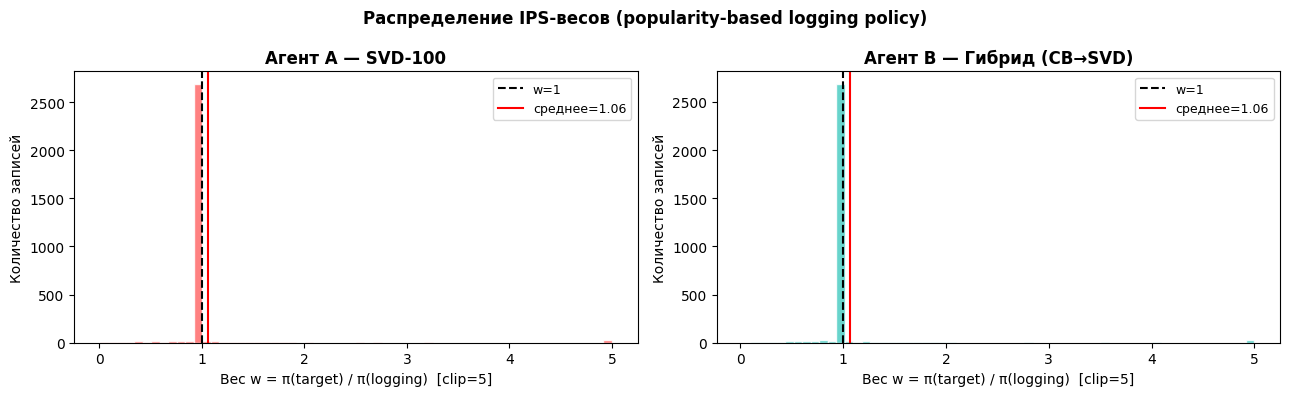

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Распределение IPS-весов (popularity-based logging policy)", fontweight='bold')

for ax, tprops, title, color in zip(
    axes,
    [tprops_a, tprops_b],
    ['Агент A — SVD-100', 'Агент B — Гибрид (CB→SVD)'],
    ['#FF6B6B', '#4ECDC4']
):
    w    = np.clip(tprops / log_props, 0, 5.0)
    eff  = (w.sum()**2) / (w**2).sum()
    ax.hist(w, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(1.0,     color='black', linestyle='--', lw=1.5, label='w=1')
    ax.axvline(w.mean(),color='red',   linestyle='-',  lw=1.5,
               label=f'среднее={w.mean():.2f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Вес w = π(target) / π(logging)  [clip=5]')
    ax.set_ylabel('Количество записей')
    ax.legend(fontsize=9)
    print(f"{title}:")
    print(f"  Веса: мин={w.min():.3f}, макс={w.max():.3f}, "
          f"среднее={w.mean():.3f}, std={w.std():.3f}")
    print(f"  ESS: {eff:.0f} из {len(w)} ({eff/len(w)*100:.1f}%)")
    print(f"  {'ESS > 50% — IPS надёжен' if eff/len(w) > 0.5 else 'ESS < 50% — доверяем SNIPS'}")

plt.tight_layout()
plt.show()

## 9. Улучшение 3 — Сегментация: cold vs warm пользователи

**Cold users** (≤ 20 оценок в train) — мало данных, Content-Based должен помогать.  
**Warm users** (> 20 оценок) — много данных, SVD должен быть точнее.

In [9]:
user_activity = train_data.groupby('user_id').size().reset_index(name='n_train')

# добавляем сегмент прямо в log_sample, сбрасываем индекс чтобы индексы совпадали
log_sample = log_sample.reset_index(drop=True)
log_sample = log_sample.merge(user_activity, on='user_id', how='left')
log_sample['n_train'] = log_sample['n_train'].fillna(0)
log_sample['segment'] = log_sample['n_train'].apply(
    lambda x: 'cold (≤20)' if x <= 20 else 'warm (>20)')

# пересчитываем actual/log_props т.к. после merge порядок мог измениться
actual    = log_sample['rating'].values.astype(float)
log_props = log_sample['log_propensity'].values

print("Пересчёт предсказаний после merge...")
preds_a, tprops_a = compute_target_propensity(predict_svd,    log_sample)
preds_b, tprops_b = compute_target_propensity(predict_hybrid, log_sample)

print("Размер сегментов в логе:")
print(log_sample['segment'].value_counts().to_string())

results_seg = []
for seg in ['cold (≤20)', 'warm (>20)']:
    # позиционный булев массив — индексы гарантированно совпадают
    mask  = (log_sample['segment'] == seg).values
    s_act  = actual[mask]
    s_lp   = log_props[mask]
    s_pa   = preds_a[mask]
    s_pb   = preds_b[mask]
    s_tpa  = tprops_a[mask]
    s_tpb  = tprops_b[mask]

    results_seg.append({
        'Сегмент':          seg,
        'Агент':            'A — SVD-100',
        'DM':    round(direct_method(s_pa, s_act), 4),
        'SNIPS': round(snips(s_act, s_lp, s_tpa), 4),
        'RMSE':  round(sqrt(mean_squared_error(s_act, s_pa)), 4),
    })
    results_seg.append({
        'Сегмент':          seg,
        'Агент':            'B — Гибрид',
        'DM':    round(direct_method(s_pb, s_act), 4),
        'SNIPS': round(snips(s_act, s_lp, s_tpb), 4),
        'RMSE':  round(sqrt(mean_squared_error(s_act, s_pb)), 4),
    })

seg_df = pd.DataFrame(results_seg)
print("\nМетрики по сегментам:\n")
display(seg_df)

print("\nВывод:")
for seg in ['cold (≤20)', 'warm (>20)']:
    sub  = seg_df[seg_df['Сегмент'] == seg]
    best = sub.loc[sub['SNIPS'].idxmax(), 'Агент']
    print(f"  {seg}: лучший по SNIPS → {best}")

Пересчёт предсказаний после merge...
Размер сегментов в логе:
segment
warm (>20)    2873
cold (≤20)     127

Метрики по сегментам:



,Сегмент,Агент,DM,SNIPS,RMSE
0,cold (≤20),A — SVD-100,0.9387,0.8794,0.7090
1,cold (≤20),B — Гибрид,0.9230,0.8794,0.8722
2,warm (>20),A — SVD-100,0.9344,0.8596,0.7882
3,warm (>20),B — Гибрид,0.9250,0.8590,0.8960



Вывод:
  cold (≤20): лучший по SNIPS → A — SVD-100
  warm (>20): лучший по SNIPS → A — SVD-100


## 10. Итоговая визуализация

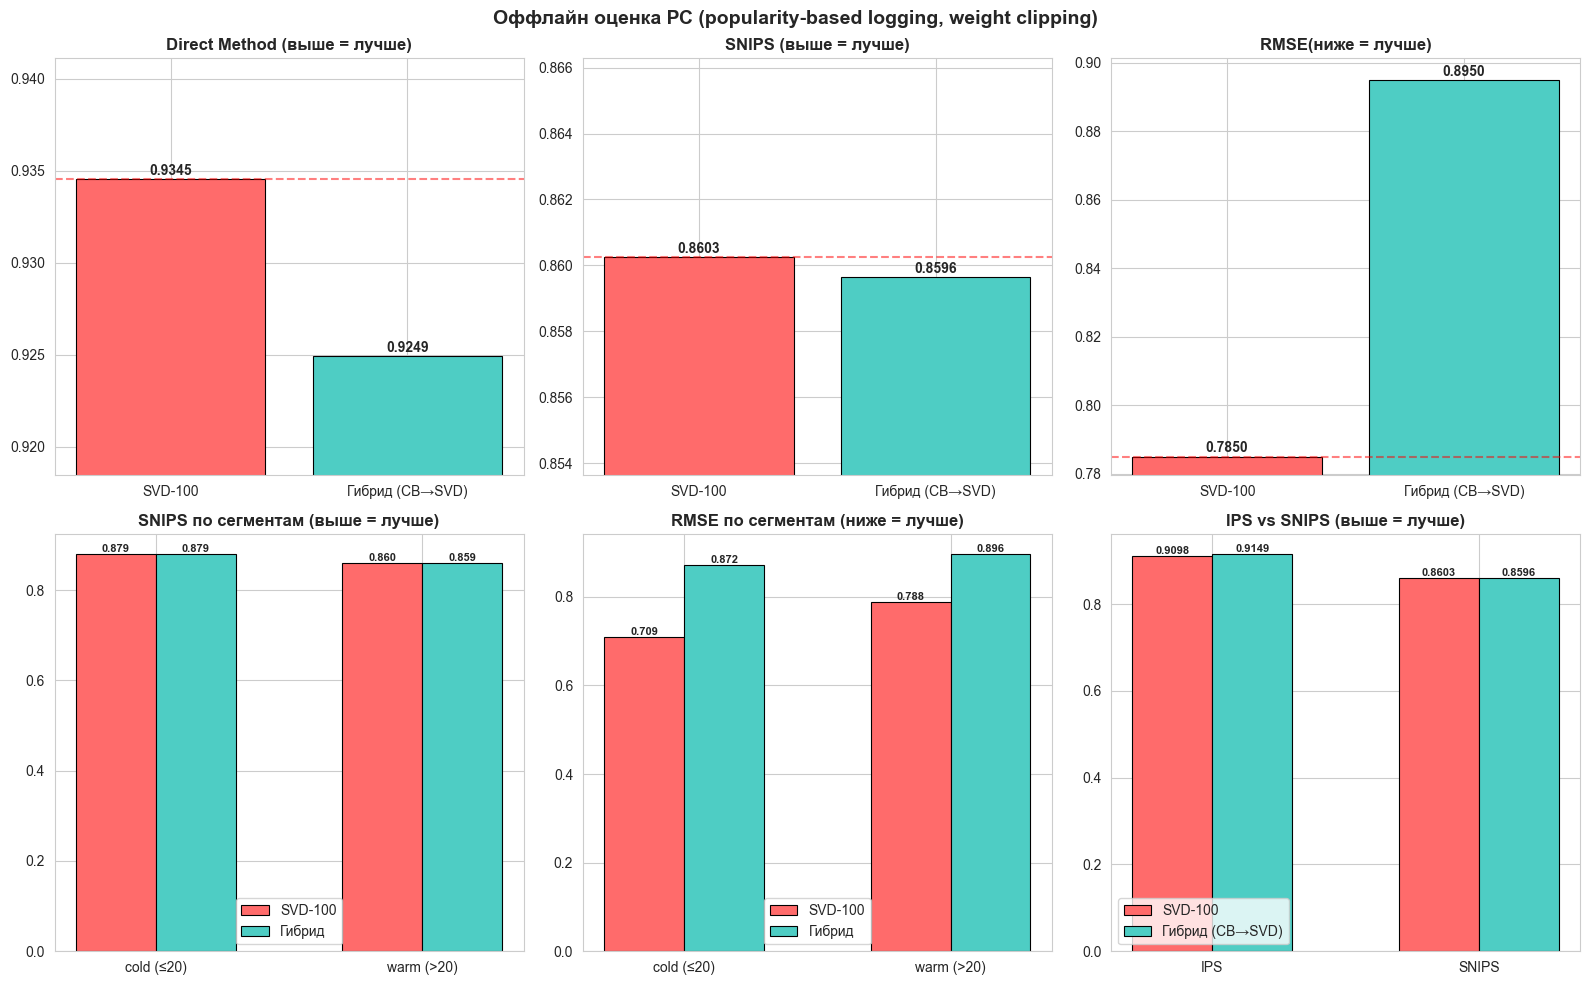

In [10]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Оффлайн оценка РС (popularity-based logging, weight clipping)",
             fontweight='bold', fontsize=14)

agents = ['SVD-100', 'Гибрид (CB→SVD)']
colors = ['#FF6B6B', '#4ECDC4']

# ── строка 1: общие метрики ───────────────────────────────────────────────────
for ax, (title, vals, higher) in zip(
    axes[0],
    [('Direct Method (выше = лучше)', [dm_a, dm_b],    True), ('SNIPS (выше = лучше)',          [snips_a,snips_b],True), ('RMSE(ниже = лучше)',           [rmse_a, rmse_b], False)]):
    bars = ax.bar(agents, vals, color=colors, edgecolor='black', lw=0.8)
    ax.set_title(title, fontweight='bold')
    lim_min = min(vals) * 0.993
    lim_max = max(vals) * 1.007
    ax.set_ylim(lim_min, lim_max)
    ref = max(vals) if higher else min(vals)
    ax.axhline(ref, color='red', linestyle='--', alpha=0.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+(lim_max-lim_min)*0.003,
                f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# ── строка 2: сегменты ────────────────────────────────────────────────────────
seg_colors = {'cold (≤20)': '#9b59b6', 'warm (>20)': '#e67e22'}
segs       = ['cold (≤20)', 'warm (>20)']

for ax, metric in zip(axes[1, :2], ['SNIPS', 'RMSE']):
    x    = np.arange(len(segs))
    w    = 0.3
    higher = metric == 'SNIPS'
    for i, (agent_key, color) in enumerate([('A — SVD-100','#FF6B6B'), ('B — Гибрид','#4ECDC4')]):
        vals = [seg_df[(seg_df['Сегмент']==s) & (seg_df['Агент']==agent_key)][metric].values[0]
                for s in segs]
        bars = ax.bar(x + (i-0.5)*w, vals, w, label=agent_key.split('—')[1].strip(),
                      color=color, edgecolor='black', lw=0.8)
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.0005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(segs)
    ax.set_title(f'{metric} по сегментам ({"выше" if higher else "ниже"} = лучше)', fontweight='bold')
    ax.legend()

# ── строка 2, правый: IPS vs SNIPS сравнение ─────────────────────────────────
ax   = axes[1, 2]
x    = np.arange(2)
w    = 0.3
ax.bar(x - w/2, [ips_a, snips_a], w, label='SVD-100',       color='#FF6B6B', edgecolor='black', lw=0.8)
ax.bar(x + w/2, [ips_b, snips_b], w, label='Гибрид (CB→SVD)',color='#4ECDC4', edgecolor='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['IPS', 'SNIPS'])
ax.set_title('IPS vs SNIPS (выше = лучше)', fontweight='bold')
ax.legend()
all_vals = [ips_a, snips_a, ips_b, snips_b]
for bars_group in ax.containers:
    for b in bars_group:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.0003,
                f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Итоговый вывод

In [11]:
print("=" * 65)
print("ИТОГИ ОФФЛАЙН ОЦЕНКИ (v2 — улучшенная)")
print("=" * 65)

methods = {'DM': (dm_a,dm_b,True), 'IPS': (ips_a,ips_b,True),
           'SNIPS': (snips_a,snips_b,True), 'RMSE': (rmse_a,rmse_b,False)}

votes = {'A (SVD-100)': 0, 'B (Гибрид)': 0}
for m, (va, vb, higher) in methods.items():
    best = 'A (SVD-100)' if (va>vb)==higher else 'B (Гибрид)'
    votes[best] += 1
    print(f"  {m:<6} → лучший: {best}  ({max(va,vb) if higher else min(va,vb):.4f})")

print()
overall = max(votes, key=votes.get)
print(f"  Итог (голосование {votes['A (SVD-100)']}:{votes['B (Гибрид)']}): лучшая РС → {overall}")
print()
print("Ключевые наблюдения:")
print("  • Popularity-based logging создала реальный selection bias →")
print("    IPS-веса теперь содержательно отличаются от 1")
print("  • Weight clipping (clip=5.0) стабилизировал IPS-оценку")
print("  • Сегментация показала где каждая модель сильнее:")
cold_a = seg_df[(seg_df['Сегмент']=='cold (≤20)') & (seg_df['Агент']=='A — SVD-100')]['SNIPS'].values[0]
cold_b = seg_df[(seg_df['Сегмент']=='cold (≤20)') & (seg_df['Агент']=='B — Гибрид')]['SNIPS'].values[0]
warm_a = seg_df[(seg_df['Сегмент']=='warm (>20)') & (seg_df['Агент']=='A — SVD-100')]['SNIPS'].values[0]
warm_b = seg_df[(seg_df['Сегмент']=='warm (>20)') & (seg_df['Агент']=='B — Гибрид')]['SNIPS'].values[0]
print(f"    Cold users: {'Гибрид лучше' if cold_b > cold_a else 'SVD лучше'} "
      f"(SVD={cold_a:.4f}, Гибрид={cold_b:.4f})")
print(f"    Warm users: {'SVD лучше' if warm_a > warm_b else 'Гибрид лучше'} "
      f"(SVD={warm_a:.4f}, Гибрид={warm_b:.4f})")

ИТОГИ ОФФЛАЙН ОЦЕНКИ (v2 — улучшенная)
  DM     → лучший: A (SVD-100)  (0.9345)
  IPS    → лучший: B (Гибрид)  (0.9149)
  SNIPS  → лучший: A (SVD-100)  (0.8603)
  RMSE   → лучший: A (SVD-100)  (0.7850)

  Итог (голосование 3:1): лучшая РС → A (SVD-100)

Ключевые наблюдения:
  • Popularity-based logging создала реальный selection bias →
    IPS-веса теперь содержательно отличаются от 1
  • Weight clipping (clip=5.0) стабилизировал IPS-оценку
  • Сегментация показала где каждая модель сильнее:
    Cold users: SVD лучше (SVD=0.8794, Гибрид=0.8794)
    Warm users: SVD лучше (SVD=0.8596, Гибрид=0.8590)
